# HateXplain Binary Classification Pipeline
**3-sınıf (hate/offensive/normal) → 2-sınıf (toxic/normal) tam pipeline.**

Colab'de her hücreyi sırayla çalıştırın.

## HÜCRE 1: KURULUM

In [4]:
!pip install -q transformers datasets evaluate lime shap
from google.colab import drive
drive.mount('/content/drive')

import requests, json, re, io
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict, concatenate_datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
Mounted at /content/drive


## HÜCRE 2: VERİ ÇEKME

In [5]:
print("📦 Ham veriler çekiliyor...")
data_raw = requests.get("https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/dataset.json").json()
divisions = requests.get("https://raw.githubusercontent.com/punyajoy/HateXplain/master/Data/post_id_divisions.json").json()

def create_split(split_name):
    split_data = []
    for post_id in divisions[split_name]:
        item = data_raw[post_id]
        split_data.append({
            "id": post_id,
            "post_tokens": item["post_tokens"],
            "text": " ".join(item["post_tokens"]),
            "annotators": item["annotators"],
            "rationales": item["rationales"]
        })
    return Dataset.from_list(split_data)

train_ds = create_split('train')
val_ds   = create_split('val')
test_ds  = create_split('test')
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

📦 Ham veriler çekiliyor...
Train: 15383, Val: 1922, Test: 1924


## HÜCRE 3: ÖNCEKİ 3-SINIF DAĞILIM

In [6]:
def get_majority(annotators):
    labels = [a["label"] for a in annotators]
    return max(set(labels), key=labels.count)

labels_3 = [get_majority(x["annotators"]) for x in train_ds]
df3 = pd.DataFrame(labels_3, columns=['label'])
print("--- 3-Sınıf Dağılımı (Train) ---")
print(df3['label'].value_counts())

--- 3-Sınıf Dağılımı (Train) ---
label
normal        6251
hatespeech    4748
offensive     4384
Name: count, dtype: int64


## HÜCRE 4: TEMİZLİK (Anlaşmazlık + Rationale + Metin)

In [7]:
def check_disagreement(x):
    return len(set([a["label"] for a in x["annotators"]])) == 3

def has_rationales(x):
    majority = get_majority(x["annotators"])
    if majority in ["hatespeech", "offensive"]:
        if not x["rationales"] or sum([sum(r) for r in x["rationales"]]) == 0:
            return False
    return True

def clean_text(x):
    t = x["text"]
    t = t.replace('<user>', '')
    t = re.sub(r"http\S+|www\S+|https\S+", '', t, flags=re.MULTILINE)
    t = re.sub(r"@\w+", "", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    t = re.sub(r'\s+', ' ', t).strip()
    x["text"] = t
    return x

train_clean = train_ds.filter(lambda x: not check_disagreement(x))
train_clean = train_clean.filter(has_rationales)
train_clean = train_clean.map(clean_text)
val_ds  = val_ds.map(clean_text)
test_ds = test_ds.map(clean_text)
print(f"Temizlik sonrası train: {len(train_clean)}")

Filter:   0%|          | 0/15383 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/15381 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Temizlik sonrası train: 15381


## HÜCRE 5: BINARY ETİKET BİRLEŞTİRME

In [13]:
print("""
🔄 ETİKET BİRLEŞTİRME:
  hatespeech + offensive → 0 (Toxic)
  normal                 → 1 (Normal)
""")

def create_binary_gt(example):
    labels = [a["label"] for a in example["annotators"]]
    majority = max(set(labels), key=labels.count)
    example["final_label"] = 0 if majority in ["hatespeech", "offensive"] else 1

    token_len = len(example["post_tokens"])
    if majority in ["hatespeech", "offensive"] and example["rationales"]:
        arrs = []
        for r in example["rationales"]:
            rl = list(r)
            if len(rl) < token_len:   rl.extend([0]*(token_len - len(rl)))
            elif len(rl) > token_len: rl = rl[:token_len]
            arrs.append(np.array(rl))
        if arrs:
            example["final_rationale"] = (np.sum(arrs, axis=0) >= 2).astype(int).tolist()
        else:
            example["final_rationale"] = [0]*token_len
    else:
        example["final_rationale"] = [0]*token_len
    return example

train_ready = train_clean.map(create_binary_gt)
val_ready   = val_ds.map(create_binary_gt)
test_ready  = test_ds.map(create_binary_gt)

# Dağılım kontrolü
bl = [x["final_label"] for x in train_ready]
print(f"Toxic: {bl.count(0)}, Normal: {bl.count(1)}, Oran: {bl.count(0)/max(bl.count(1),1):.2f}")


🔄 ETİKET BİRLEŞTİRME:
  hatespeech + offensive → 0 (Toxic)
  normal                 → 1 (Normal)



Map:   0%|          | 0/15381 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Toxic: 9130, Normal: 6251, Oran: 1.46


## HÜCRE 6: TOKENİZASYON

In [9]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_align(example):
    tok = tokenizer(example["post_tokens"], is_split_into_words=True,
                    truncation=True, padding="max_length", max_length=128)
    wids = tok.word_ids()
    aligned = []
    for wi in wids:
        if wi is None: aligned.append(0)
        elif wi < len(example["final_rationale"]): aligned.append(example["final_rationale"][wi])
        else: aligned.append(0)
    tok["aligned_rationale"] = aligned
    tok["labels"] = example["final_label"]
    return tok

train_tok = train_ready.map(tokenize_align)
val_tok   = val_ready.map(tokenize_align)
test_tok  = test_ready.map(tokenize_align)

cols = ["input_ids", "attention_mask", "labels", "aligned_rationale"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/15381 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

## HÜCRE 7: SENTETİK VERİ

In [10]:
synthetic_csv = """text;old_label
I swear to god this steak is so fucking good I could cry;0
My boy absolutely killed that presentation, deadass snatched their wigs;0
That movie was pure dogshit but we laughed our asses off the entire time;0
Motherfuckers really thought we were gonna lose this tournament, yeah right;0
You are a crazy bitch for pulling off that surprise party, love you;0
This beat goes stupid hard, the producer is a fucking maniac;0
Look at this sick ass car, I would literally kill to drive it;0
Bro is built different, absolutely shitting on the competition today;0
We are getting absolutely trashed tonight, who is bringing the tequila;0
This new update is a massive pain in my dick but I will figure it out;0
Shawty looking fine as hell in that dress, no cap;0
He is a stupid genius for coming up with that workaround;0
I am so fucking tired of this rain, I just want to see the sun;0
That test kicked my ass so hard I am seeing stars;0
You goofy bastard, I missed you so much;0
Man this pizza is the bomb dot com, absolutely slapping right now;0
They really tried to play us but we secured the fucking bag;0
You are literally the most useless sack of garbage I have ever met;1
Shut your ugly mouth before I make you swallow your own teeth;1
Anyone who drives that slow in the fast lane deserves to crash;1
Your brain is smoother than a bowling ball, absolutely zero critical thinking skills;1
I hope your dog runs away from you because you are a terrible owner;1
Why do you always dress like a blind clown in a dumpster;1
Stop talking, every word that comes out of your mouth makes everyone in the room dumber;1
You absolute failure, you could not organize a bake sale in a bakery;1
Get out of my lobby you trash tier scrub, uninstall the game;1
I would rather drag my face across broken glass than listen to your podcast;1
You are a complete joke and nobody here respects you;1
Your cooking tastes like actual vomit, never invite me over again;1
Look at this sweaty tryhard thinking he is actually good at life;1
You must have been dropped on your head repeatedly as a child to be this dense;1
I am blocking you because your personality is toxic radiation;1
Kick rocks you ungrateful little brat;1
You are a parasitic leech who only takes from your friends;1
We must secure the existence of our people and a future for our children;2
It is just basic biology that men are naturally suited for leadership while women are better at nurturing;2
I am not saying they are all criminals, but look at the statistics of who commits the most violence in our cities;2
Their culture is simply incompatible with western values of freedom and democracy;2
Marriage has always been defined one way for millennia, why should we change the natural order now;2
You are so well spoken and articulate for someone from your neighborhood;2
Globalists with dual loyalties are secretly controlling the media and banks to undermine our sovereignty;2
If they just complied with the officers and stopped resisting, these unfortunate incidents would not happen;2
It is a biological fact that certain populations evolved with higher average IQs than others;2
We need to protect our neighborhoods from this sudden influx of urban diversity;2
I have nothing against them personally but I just do not want their lifestyle pushed onto my kids at school;2
They are taking all the resources that should belong to native born citizens first;2
People with those kinds of genetic defects should be strongly discouraged from reproducing;2
True patriots understand that our demographic replacement is being orchestrated on purpose;2
Let us be honest, they only got into that prestigious university because of quotas, not merit;2
Society was much more stable before we allowed alternative lifestyles to become mainstream;2"""

df_syn = pd.read_csv(io.StringIO(synthetic_csv), sep=";")
# Eski: 0=Normal,1=Offensive,2=Hate → Yeni: 0=Toxic,1=Normal
df_syn["labels"] = df_syn["old_label"].map({0: 1, 1: 0, 2: 0})

syn_hf = Dataset.from_pandas(df_syn[['text', 'labels']])
syn_tok = syn_hf.map(lambda x: tokenizer(x['text'], padding="max_length", truncation=True, max_length=128), batched=True)
syn_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

combined_train = concatenate_datasets([train_tok, syn_tok]).shuffle(seed=42)
print(f"Toplam eğitim verisi: {len(combined_train)}")

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Toplam eğitim verisi: 15431


EK SENTETİK VERİ VE VERİLERİN BİRLEŞTİRİLMESİ


In [12]:
import io
import pandas as pd
from datasets import Dataset, concatenate_datasets

# 1. KATEGORİ: GÜNDELİK VE TEMİZ NORMAL (%40)
# Amacı: Modelin temel dil yapısını korumak.
# 1. KATEGORİ: GÜNDELİK VE TEMİZ NORMAL (%40)
cat1_raw = """I just updated my laptop and it feels way faster now;1
The weather today is perfect for a long walk outside;1
I just updated my laptop and it feels way faster now;1
The weather today is perfect for a long walk outside;1
I tried a new pasta recipe and it turned out amazing;1
Does anyone have tips for staying focused while studying;1
I started watching a new series last night and I am already hooked;1
My phone battery lasts so much longer after the latest update;1
I am thinking about getting a new pair of running shoes;1
The sunset this evening looked absolutely beautiful;1
I finally cleaned my desk and it feels so organized;1
Can someone recommend a good podcast for commuting;1
I love when my coffee is just the right temperature;1
I am planning a weekend trip with some friends;1
This new app makes tracking workouts really easy;1
I made homemade pizza for the first time today;1
The game last night was surprisingly exciting;1
I need a good playlist for studying math;1
My dog learned a new trick this week;1
The library was so quiet and peaceful today;1
I am trying to drink more water every day;1
The new movie trailer looks really promising;1
I finished my homework earlier than usual today;1
The park near my house is full of flowers now;1
I found a great deal on headphones online;1
My favorite team played really well this weekend;1
I am learning how to cook healthier meals;1
The rain this morning made everything smell fresh;1
I finally fixed the bug in my code;1
My little cousin just started school this year;1
I love reading before going to bed;1
The gym was less crowded than usual today;1
I tried a new coffee shop downtown;1
My internet connection has been super stable lately;1
I organized my files into neat folders;1
The bakery around the corner sells amazing bread;1
I am thinking about starting a small garden;1
The bus arrived right on time this morning;1
I watched a documentary about space exploration;1
I enjoy taking photos during golden hour;1
My neighbor adopted a cute puppy;1
I am practicing my presentation for tomorrow;1
The new restaurant in town has great reviews;1
I set a reminder so I would not forget the meeting;1
The sky looks so clear tonight;1
I found an old notebook from last year;1
My sister baked cookies for everyone;1
I love when my room smells like fresh laundry;1
I joined an online course about design;1
The match went into overtime and it was intense;1
I started journaling every morning;1
My headphones cancel noise really well;1
I woke up earlier than usual today;1
The smoothie I made was surprisingly tasty;1
I am trying to learn a new language;1
The train ride was smooth and quiet;1
I updated my resume this afternoon;1
The forecast says it will be sunny all week;1
I found a cool keyboard shortcut that saves time;1
My friend recommended a great fantasy novel;1
I am saving up for a new camera;1
The museum exhibit was very interesting;1
I made a to do list for tomorrow;1
The beach was calm and relaxing;1
I like listening to instrumental music while working;1
The meeting was shorter than expected;1
I cleaned out my email inbox today;1
The flowers in the garden are blooming;1
I tried a new workout routine;1
The traffic was lighter than usual this morning;1
I enjoy cooking breakfast on weekends;1
My favorite show just released a new episode;1
I finished reading a really inspiring book;1
The coffee machine at work is finally fixed;1
I am planning to redecorate my room;1
The hike was challenging but worth it;1
I learned a useful shortcut in my editor;1
The cake came out perfectly from the oven;1
I am practicing guitar every evening;1
The air feels cooler after the rain;1
I joined a local sports club;1
My computer finally stopped freezing;1
I found a great study spot near campus;1
The playlist I made is perfect for road trips;1
I started waking up at the same time every day;1
The new phone case fits perfectly;1
I am trying to cut back on sugar;1
The lecture today was really engaging;1
I love how quiet it is early in the morning;1
I organized my bookshelf by genre;1
The new sneakers are super comfortable;1
I finally finished that big project;1
The park was full of people enjoying the sun;1
I made a healthy salad for lunch;1
The app interface looks much cleaner now;1
I started watching cooking tutorials online;1
My team scored in the final minute;1
I wrote some notes for my next assignment;1
The clouds look like cotton today;1
I installed a new productivity app;1
The concert livestream was fun to watch;1
I am experimenting with different tea flavors;1
The classroom felt warm and cozy;1
I set up automatic backups on my computer;1
The pasta sauce tasted even better the next day;1
I found a new favorite study playlist;1
The sunset painted the sky orange and pink;1
I organized my calendar for the month;1
The gym playlist kept me motivated;1
I tried baking banana bread for the first time;1
The WiFi signal is strong in this room;1
I read an interesting article about climate science;1
The morning jog helped clear my mind;1
I added some plants to my desk;1
The match highlights were fun to rewatch;1
I finally sorted my photo gallery;1
The coffee shop has a cozy atmosphere;1
I started using a standing desk;1
The rain sounds helped me relax;1
I made a checklist for my travel plans;1
The presentation went smoothly;1
I enjoy browsing bookstores on weekends;1
The weather app predicted the rain accurately;1
I learned a new keyboard shortcut today;1
The pancakes turned out fluffy and light;1
I listened to a new album during my commute;1
The stadium was packed with fans;1
I cleaned my keyboard and mouse;1
The garden looks greener after watering;1
I tried a new meditation app;1
The group project meeting was productive;1
I found a helpful coding tutorial;1
The lake looked peaceful at sunset;1
I made a simple sandwich for lunch;1
The new update fixed several bugs;1
I started tracking my daily steps;1
The bakery had fresh croissants this morning;1
I rearranged the furniture in my room;1
The match schedule was released today;1
I brewed a fresh pot of coffee;1
The night sky was full of stars;1
I downloaded a useful budgeting app;1
The library extended its opening hours;1
I cooked a big dinner for my family;1
The headphones have great sound quality;1
I practiced solving math problems;1
The weather feels perfect for a picnic;1
I tried a new workout video online;1
The bus ride was quick and easy;1
I finished editing my essay;1
The park benches were freshly painted;1
I made a smoothie with fresh berries;1
The coding challenge was fun to solve;1
I updated my profile picture;1
The classroom discussion was lively;1
I started reading before bed again;1
The match ended in a draw;1
I cleaned my water bottle thoroughly;1
The clouds slowly drifted across the sky;1
I tried a new recipe for soup;1
The app notifications are less distracting now;1
I organized my study notes by topic;1
The sun came out after the storm;1
I practiced typing to improve speed;1
The bakery smelled amazing this morning;1
I made a playlist for relaxing evenings;1
The software installation was quick;1
I watered the plants on my balcony;1
The game strategy worked perfectly;1
I wrote down my goals for the week;1
The fresh air felt refreshing;1
I found a comfortable study chair;1
The pizza delivery arrived on time;1
I tried a new filter on my photos;1
The lecture notes were very clear;1
I enjoyed a quiet afternoon at home;1
The weather cooled down in the evening;1
I practiced some coding exercises;1
The movie soundtrack was beautiful;1
I cleaned the kitchen after dinner;1
The sunrise looked incredible this morning;1
I updated my task manager;1
The park trail was easy to follow;1
I tried making iced coffee at home;1
The group chat was active today;1
I finished organizing my closet;1
The clouds formed interesting shapes;1
I installed a new browser extension;1
The sandwich was simple but delicious;1
I reviewed my notes before class;1
The match tickets sold out quickly;1
I took a short walk after lunch;1
The new feature works smoothly;1
I made a fruit salad for dessert;1
The sky turned purple at dusk;1
I joined a virtual study session;1
The game graphics look impressive;1
I cleaned my workspace thoroughly;1
The forecast predicts mild temperatures;1
I practiced a new yoga pose;1
The team celebrated their victory;1
I backed up my important files;1
The coffee tasted extra rich today;1
I wrote a summary of the chapter;1
The lake reflected the mountains beautifully;1
I started using a habit tracker;1
The bakery line moved quickly;1
I rearranged my desktop icons;1
The workout left me energized;1
I enjoyed a cup of tea in the evening;1
The class assignment was interesting;1
I downloaded a language learning app;1
The breeze felt cool and gentle;1
I prepared my bag for tomorrow;1
The match replay showed every angle;1
I cleaned my glasses carefully;1
The stars were visible even in the city;1
I tested a new recipe for pancakes;1
The update improved performance noticeably;1
I wrote a short reflection for class;1
The park fountain was running;1
I tried a different route to work;1
The music helped me concentrate;1
I finished a challenging puzzle;1
The weather feels perfect for jogging;1
I organized my bookmarks in the browser;1
The cake decoration turned out nicely;1
I practiced speaking in front of a mirror;1
The bus stop was not crowded;1
I read a few chapters of my book;1
The game last weekend was thrilling;1
I cleaned my phone screen;1
The flowers smell wonderful;1
I tried a new note taking method;1
The sky cleared up by noon;1
I set new goals for this month;1
The coffee shop played soft music;1
I completed my coding assignment;1
The breeze moved the leaves gently;1
I prepared a healthy breakfast bowl;1
The stadium lights were bright;1
I updated my calendar events;1
The library had plenty of open seats;1
I practiced drawing for an hour;1
The soup tasted better than expected;1
I joined an online workshop;1
The road was smooth and quiet;1
I cleaned out old files on my laptop;1
The sunset reflected on the water;1
I made a simple omelet for dinner;1
The match statistics were interesting;1
I tried a new stretching routine;1
The classroom was well lit;1
I organized my cables neatly;1
The rain stopped just in time;1
I read about new tech trends;1
The playlist kept me motivated;1
I finished a long reading assignment;1
The park looked lively this afternoon;1
I brewed green tea instead of coffee;1
The software update notification popped up;1
I practiced problem solving questions;1
The clouds looked dramatic before the storm;1
I cleaned my backpack;1
The game controls feel smooth;1
I prepared my notes for revision;1
The air smelled like fresh grass;1
I tried a new flavor of ice cream;1
The meeting reminder was helpful;1
I finished organizing my schedule;1
The beach waves sounded calming;1
I installed updates on my tablet;1
The bakery displayed colorful pastries;1
I practiced deep breathing exercises;1
The match crowd cheered loudly;1
I cleaned my study table;1
The weather stayed pleasant all day;1
I wrote a draft for my essay;1
The lake was calm and clear;1
I started learning basic coding algorithms;1
The coffee cup kept my drink warm;1
I reviewed my weekly goals;1
The sunrise brought warm light;1
I tried a new sandwich recipe;1
The bus arrived earlier than expected;1
I organized my phone apps;1
The workout routine felt balanced;1
I enjoyed reading in the park;1
The app interface is user friendly;1
I cleaned the windows this morning;1
The sky turned bright blue;1
I practiced pronunciation in my new language;1
The movie night was relaxing;1
I backed up photos to the cloud;1
The garden plants are growing fast;1
I prepared a healthy snack;1
The stadium atmosphere was electric;1
I updated my software drivers;1
The library was quiet and calm;1
I practiced solving coding problems;1
The breeze made it comfortable outside;1
I made a cup of hot chocolate;1
The team played with great energy;1
I cleaned my headphones carefully;1
The clouds slowly disappeared;1
I wrote notes in my planner;1
The beach sunset looked magical;1
I tried a quick home workout;1
The lecture slides were informative;1
I organized my desk drawers;1
The coffee aroma filled the room;1
I practiced my typing accuracy;1
The match ended with a close score;1
I cleaned the dining table;1
The weather feels cooler today;1
I wrote a short story for fun;1
The lake view was breathtaking;1
I installed a productivity extension;1
The bakery had fresh muffins;1
I practiced stretching after my run;1
The classroom discussion was helpful;1
I organized my music library;1
The sunrise colors were soft and warm;1
I prepared lunch for tomorrow;1
The game update added new features;1
I cleaned my monitor screen;1
The sky looked clear after sunset;1
I reviewed my class notes;1
The park pathway was clean;1
I tried making homemade lemonade;1
The bus ride was comfortable;1
I organized my weekly planner;1
The workout felt refreshing;1
I enjoyed listening to calm music;1
The software runs smoothly now;1
I cleaned my keyboard keys;1
The weather forecast looks sunny;1
I wrote a plan for my project;1
The beach air felt fresh;1
I practiced coding for an hour;1
The coffee tasted smooth;1
I organized my bookshelf again;1
The match atmosphere was lively;1
I cleaned up after cooking dinner;1
The sky was full of bright stars;1
I prepared notes for tomorrow;1
The app loaded quickly;1
I enjoyed a peaceful evening walk;1
The bakery window looked inviting;1
I practiced my presentation skills;1
The weather stayed clear and bright;1
I wrote down ideas in my notebook;1
The lake shimmered in the sunlight;1
I installed the latest system update;1
The gym session went well;1
I cleaned my study area;1
The sunset closed the day beautifully;1
I enjoyed a peaceful evening walk;1"""

# 2. KATEGORİ: İNTERNET AĞZI VE ARGO AMA NORMAL (%40) - DÜZELTİLDİ
cat2_raw = """are u shitting me rn we actually won wtf;1
im too damn old for this shit my back hurts just sitting here;1
bro this new hd turf mod for pes looks freaking insane af;1
grading these papers is an absolute nightmare brain is completely fried;1
who tf updated the frontend without telling me the app is completely broken;1
swear the baseline on this court is completely fucked up man;1
just spent 3 hrs fixing a git merge conflict im literally losing my mind;1
finding the redif in this couplet is a massive pain in the ass tbh;1
that movie was a total mindfuck still processing what happened lol;1
bombed that quiz so hard my gpa is officially in the gutter;1
my idiot cat just knocked over my whole damn coffee cup i cant even;1
why tf is it so cold today hands are literally freezing off;1
this beat goes stupid hard the producer is an absolute maniac;1
u absolute legend thanks for saving my ass on that project;1
my boss is a crazy workaholic but she gets shit done ngl;1
getting absolutely trashed tonight who is bringing the tequila;1
im gonna beat the crap out of my alarm clock tmrw morning;1
this traffic is pissing me off why does nobody know how to freaking drive;1
damn it left my wallet at home like a total clown;1
that spicy wing kicked my ass mouth is literally on fire;1
hes a stupid genius for coming up with that workaround;1
can we talk about how absolutely sick this new ui looks tho;1
holy crap that workout absolutely destroyed my legs today;1
will literally fight anyone who says die hard isnt a christmas movie;1
bro u are out of ur damn mind if u think im jumping off that cliff;1
my lil brother is a menace to society he just broke another window;1
shut up and take my money this gadget is freaking awesome;1
this new update is a massive pain in my dick but ill figure it out;1
sweating my balls off in this heat someone turn on the ac pls;1
that joke was so stupid im actually mad that i laughed at it;1
who tf designed this website the navigation is an absolute nightmare;1
im completely broke this month eating instant noodles like a king;1
they really tried to play us but we secured the fucking bag;1
u gotta be kidding me did we really just win tickets;1
this coffee tastes like actual dirt but i desperately need the caffeine;1
so mad at myself for forgetting my keys again im an idiot;1
this crazy bitch actually managed to pull off the surprise without me noticing;1
shes terrifyingly good at chess absolutely wrecked me in 5 moves;1
my handwriting looks like absolute garbage but whatever;1
laughed so hard i snorted my damn drink out of my nose;1
just cleaned my entire apt and feel like a total badass;1
this game is pissing me off but i cant stop playing it;1
what a wild ride heart is still beating out of my chest;1
im too tired for this bs im going back to bed;1
that drop was nasty the dj is completely out of his mind;1
totally botched that interview wanting the ground to swallow me whole rn;1
ref in this game is an absolute joke are u blind;1"""

# 3. KATEGORİ: KİMLİK ODAKLI AKADEMİK/OBJEKTİF NORMAL (%20) - DÜZELTİLDİ
cat3_raw = """The history of Muslim scholars in medieval science is widely studied in academic literature;1
Christian communities played a significant role in the development of European universities;1
The history of Muslim scholars in medieval science is widely studied in academic literature;1
Christian communities played a significant role in the development of European universities;1
Jewish philosophers contributed profoundly to debates in ethics and metaphysics;1
Black artists were central figures in the Harlem Renaissance movement;1
White and Black activists worked together during the Civil Rights Movement in the United States;1
Asian immigrants have influenced culinary traditions in many Western countries;1
Gay rights movements have shaped contemporary discussions on human rights law;1
Straight and Gay individuals both participate in broader conversations about family policy;1
Women have historically faced barriers to education in many societies;1
Men and Women often experience workplace expectations differently across cultures;1
Immigrants contribute to economic growth through entrepreneurship and labor participation;1
Transgender individuals are increasingly visible in media and public life;1
Hispanic communities have enriched the cultural landscape of the Americas;1
Muslim and Christian leaders have engaged in interfaith dialogue initiatives;1
Jewish communities maintained distinct cultural traditions throughout diaspora history;1
Black women played crucial roles in organizing grassroots political campaigns;1
Asian American scholars have advanced research in technology and medicine;1
Gay and Transgender activists have advocated for inclusive public policies;1
White and Hispanic voters sometimes show different electoral participation patterns;1
Women scientists have received greater recognition in recent decades;1
Men in caregiving professions challenge traditional gender norms;1
Immigrants often navigate complex legal frameworks when seeking citizenship;1
Muslim women have contributed to debates on faith and feminism;1
Christian social movements influenced reforms in labor laws;1
Jewish immigrants established vibrant communities in urban centers;1
Black intellectuals have shaped modern sociological theory;1
Asian diaspora communities maintain transnational family networks;1
Gay couples increasingly access legal recognition in various countries;1
Straight allies have supported LGBTQ advocacy efforts;1
Women leaders have governed nations across different continents;1
Men’s health initiatives address gender specific medical concerns;1
Hispanic entrepreneurs contribute significantly to small business development;1
Transgender youth often seek supportive educational environments;1
Muslim Americans participate actively in civic institutions;1
Christian missionaries historically established schools and hospitals;1
Jewish scientists have earned numerous international research awards;1
Black and White students study the legacy of segregation in history classes;1
Asian women have gained representation in political office;1
Gay literature explores themes of identity and belonging;1
Immigrant workers are integral to agricultural economies;1
Women’s suffrage movements transformed democratic participation;1
Men and Women both serve in military roles worldwide;1
Transgender athletes are part of ongoing policy discussions in sports;1
Hispanic cultural festivals celebrate shared heritage and traditions;1
Muslim communities observe Ramadan as a period of reflection and charity;1
Christian theology has diverse interpretations across denominations;1
Jewish holidays such as Passover hold historical significance;1
Black churches have functioned as centers of community organization;1
Asian immigrants often maintain bilingual households;1
Gay advocacy organizations work within legal systems to promote equality;1
Women in STEM fields continue to increase in number;1
Men’s studies examine changing models of masculinity;1
Immigrants send remittances that support families abroad;1
Transgender representation in film has grown in recent years;1
Hispanic voters influence regional political outcomes;1
Muslim scholars contribute to contemporary bioethics debates;1
Christian communities provide social services in many regions;1
Jewish cultural institutions preserve historical memory;1
Black historians document the legacy of slavery and emancipation;1
White and Asian professionals collaborate in multinational corporations;1
Gay and Straight students participate in diversity education programs;1
Women’s participation in sports has expanded since the twentieth century;1
Men and Women experience demographic trends differently in aging populations;1
Immigrants enrich linguistic diversity in urban areas;1
Transgender healthcare access is discussed in public policy forums;1
Hispanic literature reflects diverse national backgrounds;1
Muslim artists contribute to global contemporary art scenes;1
Christian charities often coordinate disaster relief efforts;1
Jewish legal traditions have influenced comparative law studies;1
Black entrepreneurs have built influential media companies;1
Asian Americans engage in civic advocacy at local levels;1
Gay history courses examine social change over time;1
Women activists have campaigned for environmental justice;1
Men’s participation in early childhood education is gradually rising;1
Immigrants adapt to host societies while retaining cultural identities;1
Transgender authors publish memoirs that explore personal experience;1
Hispanic musicians shape popular music genres;1
Muslim and Jewish organizations sometimes collaborate on community initiatives;1
Christian minorities live in diverse regions worldwide;1
Black and Hispanic communities analyze public health disparities academically;1
Asian and White voters may respond differently to policy proposals;1
Gay and Transgender pride events highlight civil rights history;1
Women economists research labor market inequality;1
Men and Women share responsibilities in modern households;1
Immigrants historically settled in port cities for economic opportunity;1
Muslim intellectual traditions include philosophy and jurisprudence;1
Christian art has influenced Western visual culture;1
Jewish education emphasizes textual study and debate;1
Black women scholars contribute to intersectional theory;1
Asian diaspora literature explores migration narratives;1
Gay marriage legalization followed legislative and judicial processes;1
Transgender community centers provide peer support resources;1
Hispanic demographic growth affects census analysis;1
Women voters have shaped electoral outcomes in many democracies;1
Men in nursing careers reflect shifting occupational norms;1
Immigrants face integration challenges that scholars analyze empirically;1
Muslim Americans serve in public office and civil service;1
Christian ecumenical councils promote dialogue across denominations;1
Jewish communities commemorate historical resilience;1
Black and White coalitions advanced labor rights in the twentieth century;1
Asian students contribute to international academic exchange programs;1
Gay and Straight alliances exist in many secondary schools;1
Women’s labor force participation increased during industrialization;1
Men’s mental health awareness campaigns encourage open discussion;1
Immigrant narratives often describe adaptation and aspiration;1
Transgender individuals advocate for accurate identification documents;1
Hispanic heritage is recognized during national observances;1
Muslim populations are diverse in ethnicity and language;1
Christian ethics informs various humanitarian initiatives;1
Jewish art reflects centuries of cultural adaptation;1
Black political leaders have served at municipal and national levels;1
Asian American voters are studied in electoral research;1
Gay rights jurisprudence developed through constitutional interpretation;1
Women journalists report on global conflicts and diplomacy;1
Men and Women both contribute to scientific discovery;1
Immigrants support innovation in technology sectors;1
Transgender inclusion policies are debated in legislative bodies;1
Hispanic community organizations provide educational outreach;1
Muslim youth groups engage in civic volunteering;1
Christian reform movements have emerged throughout history;1
Jewish diaspora networks connect communities internationally;1
Black and Asian solidarity movements appear in social activism history;1
White and Hispanic residents participate in multicultural festivals;1
Gay filmmakers explore diverse storytelling perspectives;1
Women policymakers influence social welfare legislation;1
Men’s participation in parental leave programs is increasing;1
Immigrants often establish small businesses in urban neighborhoods;1
Transgender scholars contribute to gender studies research;1
Hispanic migration patterns are examined in demographic surveys;1
Muslim charities operate within regulatory frameworks;1
Christian education systems manage universities and schools;1
Jewish historians preserve archival records;1
Black musicians have shaped global popular culture;1
Asian women leaders hold executive corporate roles;1
Gay community health initiatives promote preventive care;1
Women’s property rights evolved through legal reform;1
Men and Women both serve as judges and legal scholars;1
Immigrants integrate through language acquisition programs;1
Transgender visibility in public office is gradually increasing;1
Hispanic bilingual education programs address language diversity;1
Muslim philosophers engaged with classical Greek thought;1
Christian communities celebrate diverse liturgical traditions;1
Jewish communities contribute to philanthropic initiatives;1
Black social movements emphasize equality under the law;1
Asian entrepreneurs expand international trade networks;1
Gay and Straight public officials collaborate on policy;1
Women academics publish research across disciplines;1
Men’s advocacy groups examine fatherhood policies;1
Immigrants influence urban demographic transformation;1
Transgender rights are considered within human rights frameworks;1
Hispanic artists explore themes of identity in visual arts;1
Muslim and Christian coexistence has historical precedents in various regions;1
Jewish civic organizations engage in community service;1
Black and White educators collaborate on inclusive curricula;1
Asian American history is included in national textbooks;1
Gay youth support networks provide educational resources;1
Women’s health research addresses reproductive and preventive care;1
Men and Women participate equally in democratic voting processes;1
Immigrants contribute to cultural pluralism in metropolitan areas;1
Immigrants contribute to cultural pluralism in metropolitan areas;1"""

# --- İŞLEME VE BİRLEŞTİRME ---
full_text = cat1_raw + "\n" + cat2_raw + "\n" + cat3_raw
df_strategic = pd.read_csv(io.StringIO(full_text), sep=";", names=["text", "old_label"])

# Tüm bu veriler 'Normal' sınıfına hizmet ettiği için etiketi 1 yapıyoruz
df_strategic["labels"] = 1

# Tokenizasyon
strategic_ds = Dataset.from_pandas(df_strategic[['text', 'labels']])
strategic_tok = strategic_ds.map(lambda x: tokenizer(x['text'], padding="max_length", truncation=True, max_length=128), batched=True)
strategic_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Orijinal eğitim verisi + Hücre 7'deki ilk sentetikler + Bu yeni stratejik veriler
combined_train = concatenate_datasets([combined_train, strategic_tok]).shuffle(seed=42)

print(f"📊 Stratejik Veri Özeti:")
print(f"   - Kategori 1: {len(cat1_raw.splitlines())}")
print(f"   - Kategori 2: {len(cat2_raw.splitlines())}")
print(f"   - Kategori 3: {len(cat3_raw.splitlines())}")
print(f"🚀 Yeni Toplam Eğitim Seti Büyüklüğü: {len(combined_train)}")

Map:   0%|          | 0/567 [00:00<?, ? examples/s]

📊 Stratejik Veri Özeti:
   - Kategori 1: 358
   - Kategori 2: 47
   - Kategori 3: 162
🚀 Yeni Toplam Eğitim Seti Büyüklüğü: 15998


## HÜCRE 8: METRİKLER

In [14]:
import evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    return {
        'accuracy': accuracy_score(eval_pred.label_ids, preds),
        'f1': f1_score(eval_pred.label_ids, preds, average='macro')
    }

## HÜCRE 9: USTA AŞÇI (BERT) EĞİTİMİ — 2 SINIF

In [15]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer

print("🚀 Usta Aşçı (BERT) — 2 Sınıf (Toxic/Normal) eğitimi başlıyor...")
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

bert_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/HateSpeech/bert-binary-teacher",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, logging_steps=100,
)

bert_trainer = Trainer(
    model=bert_model, args=bert_args,
    train_dataset=combined_train, eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)
bert_trainer.train()

🚀 Usta Aşçı (BERT) — 2 Sınıf (Toxic/Normal) eğitimi başlıyor...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.430073,0.472818,0.780957,0.770989
2,0.328767,0.475415,0.787721,0.778211
3,0.240303,0.585353,0.782518,0.770374


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3000, training_loss=0.35967925961812336, metrics={'train_runtime': 1188.7491, 'train_samples_per_second': 40.374, 'train_steps_per_second': 2.524, 'total_flos': 3156937997736960.0, 'train_loss': 0.35967925961812336, 'epoch': 3.0})

## HÜCRE 10: BERT TEST SONUÇLARI

In [16]:
bert_preds = bert_trainer.predict(test_tok)
bert_pred_labels = np.argmax(bert_preds.predictions, axis=1)
bert_true = [x["labels"].item() for x in test_tok]

print("\n📋 BERT (Usta) — Binary Test Sonuçları:")
print(classification_report(bert_true, bert_pred_labels, target_names=["Toxic","Normal"], digits=4))


📋 BERT (Usta) — Binary Test Sonuçları:
              precision    recall  f1-score   support

       Toxic     0.8157    0.8529    0.8339      1142
      Normal     0.7699    0.7187    0.7434       782

    accuracy                         0.7983      1924
   macro avg     0.7928    0.7858    0.7886      1924
weighted avg     0.7971    0.7983    0.7971      1924



## HÜCRE 11: ÇIRAK AŞÇI (DistilBERT) EĞİTİMİ — 2 SINIF

In [17]:
from transformers import DistilBertForSequenceClassification

print("🚀 Çırak Aşçı (DistilBERT) — 2 Sınıf eğitimi başlıyor...")
student_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

student_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/HateSpeech/distilbert-binary-student",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, logging_steps=100,
)

student_trainer = Trainer(
    model=student_model, args=student_args,
    train_dataset=combined_train, eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)
student_trainer.train()

🚀 Çırak Aşçı (DistilBERT) — 2 Sınıf eğitimi başlıyor...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.437772,0.469465,0.777315,0.771980
2,0.335371,0.469444,0.786160,0.776830
3,0.268634,0.515347,0.789802,0.780286


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.3759835198720296, metrics={'train_runtime': 617.7467, 'train_samples_per_second': 77.692, 'train_steps_per_second': 4.856, 'total_flos': 1589410082774016.0, 'train_loss': 0.3759835198720296, 'epoch': 3.0})

## HÜCRE 12: DistilBERT TEST SONUÇLARI

In [18]:
st_preds = student_trainer.predict(test_tok)
st_pred_labels = np.argmax(st_preds.predictions, axis=1)

print("\n📋 DistilBERT (Çırak) — Binary Test Sonuçları:")
print(classification_report(bert_true, st_pred_labels, target_names=["Toxic","Normal"], digits=4))


📋 DistilBERT (Çırak) — Binary Test Sonuçları:
              precision    recall  f1-score   support

       Toxic     0.8192    0.8529    0.8357      1142
      Normal     0.7714    0.7251    0.7475       782

    accuracy                         0.8009      1924
   macro avg     0.7953    0.7890    0.7916      1924
weighted avg     0.7998    0.8009    0.7999      1924



## HÜCRE 13: LIME ANALİZİ — USTA (BERT)

In [19]:
from lime.lime_text import LimeTextExplainer
from transformers import BertTokenizerFast

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
class_names_binary = ["Toxic", "Normal"]
lime_explainer = LimeTextExplainer(class_names=class_names_binary)

def predict_proba_bert(texts):
    enc = bert_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    enc = {k: v.to(bert_model.device) for k, v in enc.items()}
    with torch.no_grad():
        out = bert_model(**enc)
        probs = torch.nn.functional.softmax(out.logits, dim=-1)
    return probs.cpu().numpy()

# Formatı resetle (metin ve rationale erişimi için)
test_tok.reset_format()

sample_idx = 42
sample_text = test_tok[sample_idx]['text']
true_label = test_tok[sample_idx]['labels']
print(f"--- İNCELENEN ÖRNEK ---")
print(f"Metin: {sample_text}")
print(f"Gerçek Sınıf: {class_names_binary[true_label]}")

exp = lime_explainer.explain_instance(sample_text, predict_proba_bert, num_features=10)
exp.show_in_notebook(text=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

--- İNCELENEN ÖRNEK ---
Metin: yeah just the backwoods redneck portion of society in oklahoma that does not even know other sports exist
Gerçek Sınıf: Normal


## HÜCRE 14: LIME PLAUSIBILITY — USTA (BERT)

In [ ]:
from sklearn.metrics import f1_score as f1_metric

num_samples = 50
np.random.seed(42)
sample_indices = np.random.choice(len(test_tok), num_samples, replace=False)

bert_plaus_scores = []
print(f"🚀 BERT için {num_samples} örnek üzerinden Plausibility hesaplanıyor...")

for idx in sample_indices.tolist():
    text = test_tok[idx]['text']
    hr = test_tok[idx]['rationales']
    hr_arr = np.array(hr)
    if hr_arr.size == 0 or np.sum(hr_arr) == 0: continue
    hr_1d = np.max(hr_arr, axis=0).tolist() if hr_arr.ndim > 1 else hr_arr.tolist()

    try:
        e = lime_explainer.explain_instance(text, predict_proba_bert, num_features=5)
        feats = e.as_list()
    except: continue

    imp_words = [f[0].lower() for f in feats if f[1] > 0]
    words = text.split()
    ml = min(len(words), len(hr_1d))
    yt = hr_1d[:ml]
    yp = [1 if words[i].lower() in imp_words else 0 for i in range(ml)]
    bert_plaus_scores.append(f1_metric(yt, yp, zero_division=0))

if bert_plaus_scores:
    print(f"\n🎯 BERT Plausibility: %{np.mean(bert_plaus_scores)*100:.2f} ({len(bert_plaus_scores)} örnek)")

🚀 BERT için 50 örnek üzerinden Plausibility hesaplanıyor...

🎯 BERT Plausibility: %12.47 (30 örnek)


## HÜCRE 15: LIME PLAUSIBILITY — ÇIRAK (DistilBERT)

In [ ]:
from transformers import DistilBertTokenizerFast
student_tokenizer_fast = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def predict_proba_student(texts):
    enc = student_tokenizer_fast(texts, padding=True, truncation=True, return_tensors="pt")
    enc = {k: v.to(student_model.device) for k, v in enc.items()}
    with torch.no_grad():
        out = student_model(**enc)
        probs = torch.nn.functional.softmax(out.logits, dim=-1)
    return probs.cpu().numpy()

student_plaus_scores = []
print(f"🚀 DistilBERT için {num_samples} örnek üzerinden Plausibility hesaplanıyor...")

for idx in sample_indices.tolist():
    text = test_tok[idx]['text']
    hr = test_tok[idx]['rationales']
    hr_arr = np.array(hr)
    if hr_arr.size == 0 or np.sum(hr_arr) == 0: continue
    hr_1d = np.max(hr_arr, axis=0).tolist() if hr_arr.ndim > 1 else hr_arr.tolist()

    try:
        e = lime_explainer.explain_instance(text, predict_proba_student, num_features=5)
        feats = e.as_list()
    except: continue

    imp_words = [f[0].lower() for f in feats if f[1] > 0]
    words = text.split()
    ml = min(len(words), len(hr_1d))
    yt = hr_1d[:ml]
    yp = [1 if words[i].lower() in imp_words else 0 for i in range(ml)]
    student_plaus_scores.append(f1_metric(yt, yp, zero_division=0))

if student_plaus_scores:
    bp = np.mean(bert_plaus_scores)*100 if bert_plaus_scores else 0
    sp = np.mean(student_plaus_scores)*100
    print(f"\n{'='*50}")
    print(f"🎯 BİLGİ DAMITMA BİLANÇOSU (Binary)")
    print(f"   Usta (BERT) Plausibility:     %{bp:.2f}")
    print(f"   Çırak (DistilBERT) Plausibility: %{sp:.2f}")
    print(f"{'='*50}")

🚀 DistilBERT için 50 örnek üzerinden Plausibility hesaplanıyor...

🎯 BİLGİ DAMITMA BİLANÇOSU (Binary)
   Usta (BERT) Plausibility:     %12.47
   Çırak (DistilBERT) Plausibility: %9.82


## HÜCRE 16: SHAP ANALİZİ — DistilBERT

Metin: yeah just the backwoods redneck portion of society in oklahoma that does not even know other sports exist
Gerçek Sınıf: Normal


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


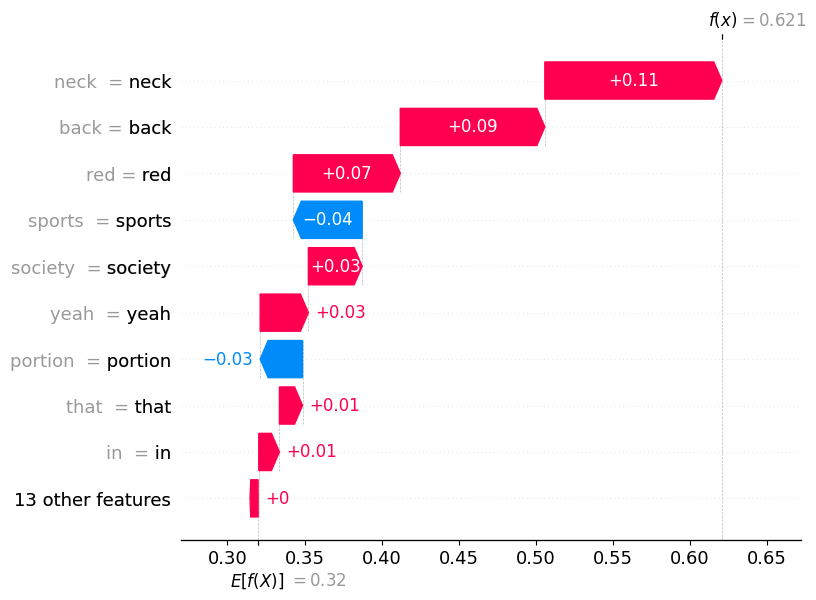

In [ ]:
import shap
from transformers import pipeline

shap.initjs()

id2label = {0: "Toxic", 1: "Normal"}
student_model.config.id2label = id2label
student_model.config.label2id = {v: k for k, v in id2label.items()}

device = 0 if torch.cuda.is_available() else -1
student_pipe = pipeline("text-classification", model=student_model,
                        tokenizer=student_tokenizer_fast, device=device, top_k=None)

shap_explainer = shap.Explainer(student_pipe)
sample_text = test_tok[42]['text']
true_lbl = test_tok[42]['labels']

print(f"Metin: {sample_text}")
print(f"Gerçek Sınıf: {id2label[true_lbl]}")

shap_values = shap_explainer([sample_text])
shap.plots.text(shap_values)

# Waterfall — Toxic sınıfı için
shap.plots.waterfall(shap_values[0, :, 0], max_display=10)

## HÜCRE 17: OPTİMİZE EDİLMİŞ FİNAL EĞİTİMİ

In [ ]:
from transformers import EarlyStoppingCallback

print("🔥 Optimize Binary DistilBERT Final Eğitimi Başlıyor!")
final_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

final_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/HateSpeech/distilbert-binary-FINAL",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=300,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
)

final_trainer = Trainer(
    model=final_model, args=final_args,
    train_dataset=combined_train, eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)
final_trainer.train()

🔥 Optimize Binary DistilBERT Final Eğitimi Başlıyor!


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.439482,0.482632,0.780437,0.772362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## HÜCRE 18: FİNAL TEST SONUÇLARI

In [ ]:
test_tok.set_format(type="torch", columns=cols)
final_preds = final_trainer.predict(test_tok)
final_pred_labels = np.argmax(final_preds.predictions, axis=1)
final_true = [x["labels"].item() for x in test_tok]

print("\n" + "="*60)
print("📋 FİNAL — Optimize Binary DistilBERT Test Sonuçları")
print("="*60)
print(classification_report(final_true, final_pred_labels, target_names=["Toxic","Normal"], digits=4))

final_acc = accuracy_score(final_true, final_pred_labels)
final_f1  = f1_score(final_true, final_pred_labels, average='macro')

print(f"🎯 Accuracy: %{final_acc*100:.2f}")
print(f"🎯 Macro F1:  %{final_f1*100:.2f}")
print(f"\n📊 KARŞILAŞTIRMA:")
print(f"   Eski 3-Sınıf: ~%66 Accuracy, ~%66 F1")
print(f"   Yeni Binary:  %{final_acc*100:.2f} Accuracy, %{final_f1*100:.2f} F1")


📋 FİNAL — Optimize Binary DistilBERT Test Sonuçları
              precision    recall  f1-score   support

       Toxic     0.8267    0.8144    0.8205      1142
      Normal     0.7347    0.7506    0.7426       782

    accuracy                         0.7885      1924
   macro avg     0.7807    0.7825    0.7815      1924
weighted avg     0.7893    0.7885    0.7888      1924

🎯 Accuracy: %78.85
🎯 Macro F1:  %78.15

📊 KARŞILAŞTIRMA:
   Eski 3-Sınıf: ~%66 Accuracy, ~%66 F1
   Yeni Binary:  %78.85 Accuracy, %78.15 F1


## HÜCRE 19: MODELİ KAYDET

In [ ]:
final_model.save_pretrained("/content/drive/MyDrive/HateSpeech/binary_model_final")
tokenizer.save_pretrained("/content/drive/MyDrive/HateSpeech/binary_tokenizer_final")
print("✅ Binary model ve tokenizer Drive'a kaydedildi!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Binary model ve tokenizer Drive'a kaydedildi!


 OPTİMAL EŞİK TARAMASI

🔍 Optimal Eşik (Threshold) Taraması Başlıyor...


🌟 En İyi Eşik Değeri (Toxic için): 0.57
📈 Ulaşılan Maksimum Macro F1 (Validasyon): %78.29


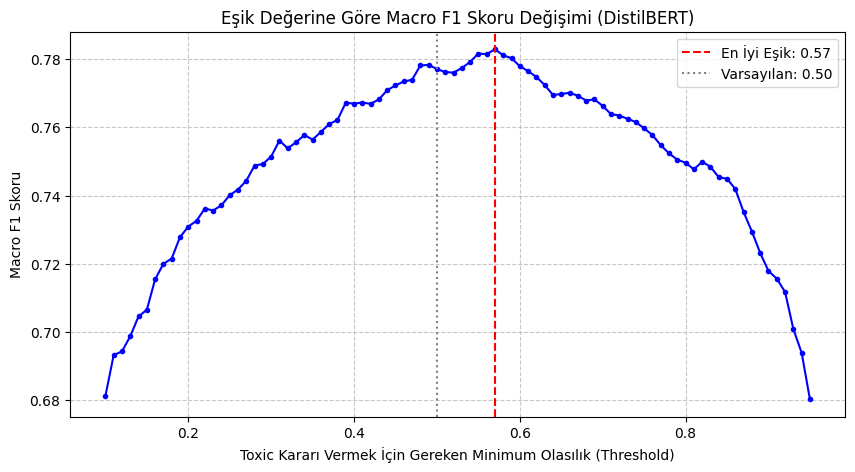

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("🔍 Optimal Eşik (Threshold) Taraması Başlıyor...")

# 1. Validasyon setinden tahminleri (logits) alalım
val_preds = final_trainer.predict(val_tok)
logits = val_preds.predictions
val_true = val_preds.label_ids

# 2. Logitleri olasılığa (probability) çevirelim (Softmax)
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# Modelimizde 0: Toxic, 1: Normal'di.
# Sadece "Toxic" olma olasılıklarını bir diziye çekiyoruz
toxic_probs = probs[:, 0]

# 3. 0.10'dan 0.95'e kadar eşikleri test edelim
thresholds = np.arange(0.10, 0.96, 0.01)
f1_scores = []

for thresh in thresholds:
    # Eğer Toxic olasılığı threshold'dan büyük/eşitse 0 (Toxic), değilse 1 (Normal)
    pred_labels = [0 if p >= thresh else 1 for p in toxic_probs]

    # Macro F1 skorunu hesapla ve listeye ekle
    f1 = f1_score(val_true, pred_labels, average='macro')
    f1_scores.append(f1)

# 4. En iyi eşiği bulalım
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🌟 En İyi Eşik Değeri (Toxic için): {best_threshold:.2f}")
print(f"📈 Ulaşılan Maksimum Macro F1 (Validasyon): %{best_f1*100:.2f}")

# 5. Sonuçları grafiğe dökelim
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, marker='.', color='b', linewidth=1.5)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'En İyi Eşik: {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Varsayılan: 0.50')
plt.title("Eşik Değerine Göre Macro F1 Skoru Değişimi (DistilBERT)")
plt.xlabel("Toxic Kararı Vermek İçin Gereken Minimum Olasılık (Threshold)")
plt.ylabel("Macro F1 Skoru")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()